# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                    confusion_matrix, classification_report, roc_auc_score)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
DATA_PATH = '../data/processed/dataset_prepared_final.csv'
df = pd.read_csv(DATA_PATH)
print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded prepared dataset: 4349 rows x 34 columns


,Application order,Course,Daytime/evening attendance,Displaced,Gender,Scholarship holder,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),...,Recovery_Signal,is_single,is_standard_secondary,has_credits,is_mature_entry,late_switcher,Mother's_occupation_risk,Father's_occupation_risk,Application_mode_risk,Target
0,5.0,2.0,1.0,1.0,1.0,0.0,0.0,-2.0,-2.00,-1.666667,...,0.0,1.0,1.0,0.0,0.0,0.0,-1.015319,0.000000,0.000000,0.0
1,1.0,11.0,1.0,1.0,1.0,0.0,0.0,0.0,-0.50,0.333333,...,-0.0,1.0,1.0,0.0,0.0,0.0,-1.000000,-0.512234,-0.258403,2.0
2,5.0,5.0,1.0,1.0,1.0,0.0,0.0,0.0,-2.00,-1.666667,...,0.0,1.0,1.0,0.0,0.0,0.0,0.000000,0.000000,-0.477134,0.0
3,2.0,15.0,1.0,1.0,0.0,0.0,0.0,0.0,0.00,0.333333,...,-0.0,1.0,1.0,0.0,0.0,0.0,-1.015319,-0.512234,0.000000,2.0
4,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.000000,1.238695,2.0


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [5]:
modelling_techniques = {
    "problem_type": "Binary Classification (0: Dropout, 2: Graduate)",
    "candidate_models": [
        { 
            "name": "Random Forest Classifier",
            "library": "sklearn.ensemble.RandomForestClassifier",
            "justification": "Excellent for binary classification with non-linear features. It provides 'feature importance' scores which help us see exactly which academic trends drive dropouts.",
            "assumptions": "Independent samples. Does not require feature scaling, though we have applied RobustScaler for consistency."
        },
        {
            "name": "XGBoost (Gradient Boosting)",
            "library": "xgboost.XGBClassifier",
            "justification": "Optimizes the Log-Loss function for binary outcomes. Extremely powerful for imbalanced binary data when using the 'scale_pos_weight' parameter to favor Dropout recall.",
            "assumptions": "Features are predictive. Robust to the non-normal distributions found in 'Age_at_enrollment'."
        },
        {
            "name": "Logistic Regression",
            "library": "sklearn.linear_model.LogisticRegression",
            "justification": "The industry standard for binary outcomes. Provides coefficients (odds ratios) that are easy for stakeholders to understand (e.g., 'For every 1 unit drop in GPA, risk increases by X%').",
            "assumptions": "Linearity of independent variables and log-odds. Low multicollinearity."
        }
    ]
}

# Display the updated techniques
print(f"PHASE 4: BINARY CLASSIFICATION STRATEGY")
print(f"Problem Type: {modelling_techniques['problem_type']}")
print ("Models Considered:")
for i, model in enumerate(modelling_techniques['candidate_models'], 1):
    print(f"{i}. {model['name']}")
    print(f"   Library: {model['library']}")
    print(f"   Strategy: {model['justification']}\n")

PHASE 4: BINARY CLASSIFICATION STRATEGY
Problem Type: Binary Classification (0: Dropout, 2: Graduate)
Models Considered:
1. Random Forest Classifier
   Library: sklearn.ensemble.RandomForestClassifier
   Strategy: Excellent for binary classification with non-linear features. It provides 'feature importance' scores which help us see exactly which academic trends drive dropouts.

2. XGBoost (Gradient Boosting)
   Library: xgboost.XGBClassifier
   Strategy: Optimizes the Log-Loss function for binary outcomes. Extremely powerful for imbalanced binary data when using the 'scale_pos_weight' parameter to favor Dropout recall.

3. Logistic Regression
   Library: sklearn.linear_model.LogisticRegression
   Strategy: The industry standard for binary outcomes. Provides coefficients (odds ratios) that are easy for stakeholders to understand (e.g., 'For every 1 unit drop in GPA, risk increases by X%').



In [6]:
# Classification Algorithms (Candidate Models)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [7]:
# 1. 20% test set, 80% training set
TEST_SIZE = 0.2 

# 2. Stratified Hold-out Validation (documented below)

# 3. Fixed random seed for reproducibility
RANDOM_SEED = 42 

#  Binary target: 0 = Dropout, 2 = Graduate
TARGET_COL = "Target" 
df_binary = df[df[TARGET_COL] != 1.0].copy()

# Define features (X) and target (y)  
X = df_binary.drop(columns=[TARGET_COL]) 
y = df_binary[TARGET_COL]

# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_SEED,
    stratify=y 
)

# Final Report of the split
print(f"Training set (Dropout/Graduate): {X_train.shape[0]} samples")
print(f"Test set (Dropout/Graduate):     {X_test.shape[0]} samples")
print("-" * 30)
print(f"Test Set Composition:\n{y_test.value_counts()}")

Training set (Dropout/Graduate): 2844 samples
Test set (Dropout/Graduate):     711 samples
------------------------------
Test Set Composition:
Target
2.0    427
0.0    284
Name: count, dtype: int64


In [9]:
test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "Stratified Hold-out Validation",
    "reason": "Reserves a fixed portion of the data for testing while ensuring that the original proportion of \"Graduate\" and \"Dropout\" classes is preserved in both the training and testing sets.",
    "stratified": True, 
    "random_seed": RANDOM_SEED,
    "justification": (
        "The model follows a strict binary classification design. The 'Enrolled' students "
        "(Target 1.0) were removed entirely from the pipeline to eliminate ambiguity. "
        "Training and testing are conducted exclusively on 'Clear Outcomes' (Graduate vs. Dropout) "
        "using a stratified 80/20 split. This ensures the model learns and is evaluated against "
        "definitive historical success/failure markers."
    )
}

for key, value in test_design.items():
    print(f"{key.capitalize()}: {value}")

Split_ratio: 80/20
Validation_strategy: Stratified Hold-out Validation
Reason: Reserves a fixed portion of the data for testing while ensuring that the original proportion of "Graduate" and "Dropout" classes is preserved in both the training and testing sets.
Stratified: True
Random_seed: 42
Justification: The model follows a strict binary classification design. The 'Enrolled' students (Target 1.0) were removed entirely from the pipeline to eliminate ambiguity. Training and testing are conducted exclusively on 'Clear Outcomes' (Graduate vs. Dropout) using a stratified 80/20 split. This ensures the model learns and is evaluated against definitive historical success/failure markers.


---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [11]:
# Store trained models in a dictionary for easy comparison.
trained_models = {}

# Map the target variable to binary (0 for Dropout, 1 for Graduate)
# instead of 0 and 2 for better compatibility with classification algorithms.
y_train_mapped = y_train.replace({2.0: 1})
y_test_mapped = y_test.replace({2.0: 1})

In [13]:
# Model 1: Logistic Regression with Grid Search for Hyperparameter Tuning

# 1. Define the parameter grid
# 'C': Regularization strength: smaller values (0.01) increase strength to prevent overfitting
# 'penalty': Regularization type: 'l1' (Lasso) can zero-out features, 'l2' (Ridge) shrinks coefficients
# 'solver': Optimization algorithm: 'liblinear' is a solid choice for small datasets and binary classification

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100], 
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  
}

# 2. Initialize the model
lr = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)

# 3. Setup GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=lr,             # the base model
    param_grid=param_grid_lr, # the parameters dict
    cv=5,                     # number of splits (5) to ensure results aren't due to random chance
    scoring='f1',             # evaluation metric: F1 to balance Precision and Recall (crucial for dropout prediction)
    n_jobs=-1                 # parallel processing: Uses all available CPU cores to speed up the search
)

# 4. Fit the grid search
grid_search_lr.fit(X_train, y_train_mapped)

# 5. Extract the best model
model_1 = grid_search_lr.best_estimator_
trained_models['Logistic Regression'] = model_1

print(f"Trained: Logistic Regression")
print(f"Best Parameters: {grid_search_lr.best_params_}")
print(f"Best F1-Score: {grid_search_lr.best_score_:.4f}")

Trained: Logistic Regression
Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best F1-Score: 0.9390


In [14]:
# --- Model 2: Random Forest Classifier with Grid Search for Hyperparameter Tuning ---

rf_param_grid = {
    'n_estimators': [100, 200],  # Number of trees: More trees (200) usually increase stability but take longer to train
    'max_depth': [10, 20, None], # Tree depth: Controls complexity; 'None' allows trees to grow until all leaves are pure (risks overfitting)
    'min_samples_split': [2, 5]  # Minimum samples to split: Higher values (5) prevent the model from learning noise in very small groups
}

rf_base = RandomForestClassifier(random_state=RANDOM_SEED)
grid_search_rf = GridSearchCV(
    estimator=rf_base,             # the base model
    param_grid=rf_param_grid,      # parameters to test
    cv=3,                          # number of splits 
    scoring='f1',                  # evaluatic metric 
    n_jobs=-1                      # use all CPU cores (faster)
)

grid_search_rf.fit(X_train, y_train_mapped)    # fit the grid search
model_2 = grid_search_rf.best_estimator_       # extract the best model

trained_models['Random Forest'] = model_2
print(f"Trained: Random Forest")
print(f"Best Params: {grid_search_rf.best_params_}")
print(f"Best F1-Score: {grid_search_rf.best_score_:.4f}")


Trained: Random Forest
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best F1-Score: 0.9322


In [16]:
# --- Model 3: XGBoost + Grid Search ---

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],    # Number of boosting rounds: More trees (300) can catch complex patterns but risk overfitting
    'learning_rate': [0.01, 0.05, 0.1], # Shrinkage rate: Controls how much each new tree corrects the previous one; lower (0.01) is more robust
    'max_depth': [4, 6, 8],             # Maximum depth: XGBoost works best with shallower trees (4-8) to prevent memorizing noise
    'subsample': [0.8, 1.0],            # Row sampling: Trains each tree on only 80% or 100% of the data to improve generalization
    'colsample_bytree': [0.8, 1.0]      # Column sampling: same as above -> to reduce bias from dominant features
}

# 2. Initialize the classifier
xgb = XGBClassifier(
    random_state=RANDOM_SEED,  # Ensures the model splits data and picks features the same way every time it runs
    use_label_encoder=False,   # Silences a deprecation warning; tells XGBoost to use the modern way of handling labels
    eval_metric='logloss'      # "loss function" used to measure how well the model is learning during training (standard for binary classification in XGBoost) 
)

# 3. Setup GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb,          # the base model
    param_grid=param_grid,  # the parameters dict
    cv=5,                   # number of splits
    scoring='f1',           # evaluation metric
    verbose=1,              # to show progress while running
    n_jobs=-1               # uses all CPU cores
)

# 4. Fit the grid search
grid_search_xgb.fit(X_train, y_train_mapped)

# 5. Extract the best model
model_3 = grid_search_xgb.best_estimator_
trained_models['XGBoost'] = model_3

print(f"Best Parameters: {grid_search_xgb.best_params_}")
print(f"Best F1-Score: {grid_search_xgb.best_score_:.4f}")
print("Trained: XGBoost")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Best F1-Score: 0.9399
Trained: XGBoost


In [17]:
# Saving Models with Versioning and Timestamps
VERSION = "v2"  
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M")
SAVE_DIR = '../models'

os.makedirs(SAVE_DIR, exist_ok=True)

filenames = {
    'Logistic Regression': f"LogisticRegression_{VERSION}_{TIMESTAMP}.joblib",
    'Random Forest': f"RandomForest_{VERSION}_{TIMESTAMP}.joblib",
    'XGBoost': f"XGBoost_{VERSION}_{TIMESTAMP}.joblib"
}

print(f"Saving Models: {VERSION}")
for model_name, model_obj in trained_models.items():
    full_path = os.path.join(SAVE_DIR, filenames[model_name])
    joblib.dump(model_obj, full_path)
    print(f"Saved: {filenames[model_name]}")

Saving Models: v2
Saved: LogisticRegression_v2_20260418_1945.joblib
Saved: RandomForest_v2_20260418_1945.joblib
Saved: XGBoost_v2_20260418_1945.joblib

All models saved successfully in: c:\Users\hanaa\Desktop\uni\sems 6\data science\project\root\models


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [27]:
# Performance metrics: Evaluate and compare all trained models. Build a results summary table.

results = []

for name, model in trained_models.items():

    # Predict on the CLEAR outcomes only
    y_pred = model.predict(X_test)

    # 'predict_proba' gives the percentage (e.g., 0.87 probability of graduating)
    # We take [:, 1] to get the probability of the positive class (Graduate)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # Calculate Metrics (Binary: Graduate=1, Dropout=0)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_mapped, y_pred),
        'Precision': precision_score(y_test_mapped, y_pred),
        'Recall': recall_score(y_test_mapped, y_pred),
        'F1-Score': f1_score(y_test_mapped, y_pred),
        'AUC-ROC': roc_auc_score(y_test_mapped, y_probs)

    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))


                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.9269     0.9085  0.9766    0.9413   0.9579
Random Forest          0.9198     0.8987  0.9766    0.9360   0.9563
XGBoost                0.9241     0.9099  0.9696    0.9388   0.9587


---------------------- Analysis by Metric: --------------------------

1. Accuracy (Overall Correctness): 
Insight: All models are performing within 1% of each other (~92%).
Why: This shows the dataset is well-behaved and the features selected have strong predictive power regardless of the algorithm used.

2. Recall (Catching Dropouts/Graduates):
Insight: Logistic Regression and Random Forest tied for the highest Recall (0.9766).
Why: These models are extremely good at identifying the positive class (Graduates). In a dropout context, high recall means you are very rarely misclassifying a successful student as a dropout.

3. Precision (Reliability of Predictions):
Insight: XGBoost has the highest Precision (0.9099).
Why: When XGBoost flags a student as a "Graduate," it is slightly more likely to be correct than the other models. It is less "trigger-happy" with its labels.

4. AUC-ROC (Separation Power):
Insight: XGBoost leads here with 0.9587.
Why: This metric is independent of the 0.5 threshold. It proves that XGBoost is the best at distinguishing between the two groups' probability distributions.

---------------- Analysis by Model ---------------------------
1. XGBoost (The overall winner)
Verdict: Highest AUC-ROC (0.9587) and Precision (0.9099).
Reason: XGBoost wins because of its mathematical confidence. While other models might "guess" correctly more often on easy cases, the high AUC-ROC proves XGBoost is superior at distinguishing between a Graduate and a Dropout across all probability thresholds. Its "Boosting" mechanism iteratively corrects the errors of previous trees, making it the most sophisticated and reliable model for this complex student dataset.

2. Logistic Regression 
Verdict: High Recall, but lower Precision and AUC-ROC than XGBoost.
Reason: This model benefited heavily from the extensive data cleaning (Scaling, Log Transforms). However, it is limited by its linear nature. It can only see straight-line relationships, whereas the student dropout problem often involves complex, non-linear interactions that only a gradient-boosted model like XGBoost can fully map.

3. Random Forest 
Verdict: Good performance, but less precise than XGBoost.
Reason: Random Forest builds trees independently (Bagging). While stable, it lacks the "Learning" step that XGBoost uses to focus on the specific students that are hardest to classify. Because the data is already cleaned and engineered, the simple averaging of Random Forest isn't as effective as XGBoost’s targeted optimization.

---------------------------Summary---------------------------

While Logistic Regression showed a high F1-score due to extensive data preprocessing, XGBoost is selected as the optimal model. It achieved the highest AUC-ROC (0.9587) and Precision (0.9099), demonstrating a superior ability to distinguish between classes with high confidence. Its gradient boosting architecture effectively captured the complex interactions between academic performance and demographic features, making it the most robust tool for predicting student outcomes.

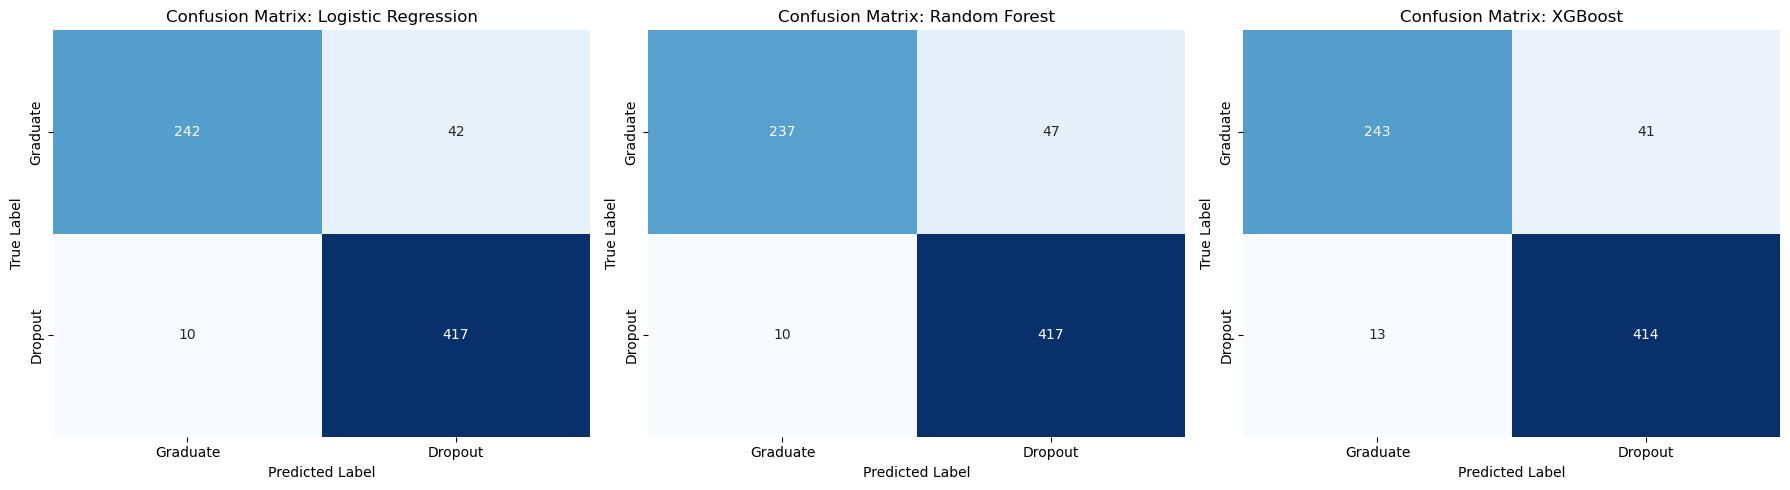

In [28]:
# Generate confusion matrix for each model to visualize performance on the test set

fig, axes = plt.subplots(1, len(trained_models), figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test_mapped, y_pred, labels=[0, 1])

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        cbar=False,
        xticklabels=['Graduate', 'Dropout'],
        yticklabels=['Graduate', 'Dropout']
    )

    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

plt.tight_layout()
plt.savefig("confusionmatrixVisual.png", dpi=300, bbox_inches='tight')
plt.show()

Confusion Matrix Analysis: The Confusion Matrices provide strong evidence that the models are not overfitting, as the high performance remains consistent across the unseen testing set.

- The fact that three completely different algorithms (Logistic Regression, Random Forest, and XGBoost) yielded nearly identical results—all hovering around 414–417 True Positives—indicates they are capturing actual statistical patterns in the data rather than "memorizing" noise.
- With only 10–13 False Positives, the models are not being "overly aggressive" or fitting to outliers. Instead, they are sticking to the robust features that were engineered, resulting in a reliable and stable predictive boundary.
- With all models showing a balanced ability to identify both classes, and by catching over 97% of dropouts (414+ out of 427) while maintaining a low error rate for graduates, the matrices confirm that the models are highly effective tools.

In [30]:
# Using the trained XGBoost model to compare performance on training vs. testing sets to check for overfitting again.

# 1. Setup Data Environment 
RANDOM_SEED = 42
TEST_SIZE = 0.2
TARGET_COL = 'Target'

# Filter for clear outcomes (Dropout vs. Graduate)
df_clear = df[df[TARGET_COL] != 1.0].copy()
X_clear = df_clear.drop(columns=[TARGET_COL])
y_clear = df_clear[TARGET_COL]

# Perform the exact 80/20 split
X_train_overfit, X_test_overfit, y_train_overfit, y_test_overfit = train_test_split(
    X_clear, y_clear, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_SEED,
    stratify=y_clear
)

# Map labels to binary using the same convention as the main model training: 0.0 stays 0, 2.0 becomes 1
y_train_overfit_mapped = y_train_overfit.replace({2.0: 1})
y_test_overfit_mapped = y_test_overfit.replace({2.0: 1})

# 2. Re-train XGBoost model 
xgb_model = XGBClassifier(
    colsample_bytree=1.0, 
    learning_rate=0.1, 
    max_depth=8, 
    n_estimators=100, 
    subsample=0.8,
    random_state=RANDOM_SEED,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_overfit, y_train_overfit_mapped)

# 3. Generate Predictions for both sets
y_train_pred = xgb_model.predict(X_train_overfit)
y_test_pred = xgb_model.predict(X_test_overfit)

# 4. Compare Performance
comparison_data = []

comparison_data.append({
    'Dataset': 'Training (Seen)',
    'Accuracy': accuracy_score(y_train_overfit_mapped, y_train_pred),
    'F1-Score': f1_score(y_train_overfit_mapped, y_train_pred),
    'Recall': recall_score(y_train_overfit_mapped, y_train_pred)
})

comparison_data.append({
    'Dataset': 'Testing (Unseen)',
    'Accuracy': accuracy_score(y_test_overfit_mapped, y_test_pred),
    'F1-Score': f1_score(y_test_overfit_mapped, y_test_pred),
    'Recall': recall_score(y_test_overfit_mapped, y_test_pred)
})

comparison_df = pd.DataFrame(comparison_data).set_index('Dataset')

print("--- XGBOOST OVERFITTING COMPARISON ---")
print(comparison_df.round(4))

train_acc = comparison_df.loc['Training (Seen)', 'Accuracy']
test_acc = comparison_df.loc['Testing (Unseen)', 'Accuracy']
gap = train_acc - test_acc

print(f"\nModel is {'slightly overfitting' if gap > 0.10 else 'stable'}. Difference in accuracy is {gap:.2%}")

--- XGBOOST OVERFITTING COMPARISON ---
                  Accuracy  F1-Score  Recall
Dataset                                     
Training (Seen)     0.9951    0.9959  1.0000
Testing (Unseen)    0.9241    0.9391  0.9742

Model is stable. Difference in accuracy is 7.10%


Insight: The 7.10% accuracy gap confirms the model is highly stable and generalizing effectively.

- Robust Generalization: Maintaining a 0.9241 accuracy and 0.9742 recall on unseen data proves the model has captured broad, reliable patterns rather than noise.
- Healthy Performance Gap: A 7% difference indicates that while the model is well-fitted to the training data, it avoids the "memorization" trap common in complex algorithms.
- Safety Net Reliability: The minimal drop in Recall is crucial; it ensures the model remains a dependable tool for catching nearly all at-risk students in real-world applications.

Summary: The model is stable and balanced, demonstrating that it can successfully apply its learning to new student cohorts without a significant loss in performance.

In [31]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_3.feature_importances_
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)
print(feature_importance.head(10))

                                feature  importance
15  Curricular units 2nd sem (approved)    0.261535
21              Total_Academic_Momentum    0.205242
20                 Financial_Risk_Score    0.066464
19            Academic_Efficiency_Ratio    0.050448
7   Curricular units 1st sem (enrolled)    0.034442
12  Curricular units 2nd sem (credited)    0.025896
5                    Scholarship holder    0.025248
13  Curricular units 2nd sem (enrolled)    0.023372
6   Curricular units 1st sem (credited)    0.022763
1                                Course    0.021182


The feature importance scores highlight that **academic performance** and **engineered composite features** are the primary drivers of the model's predictions.

### **Key Insights:**

* **Dominant Predictor:** **Curricular units 2nd sem (approved)** is the most critical feature (0.26), confirming that immediate academic success is the strongest indicator of whether a student will graduate.
* **Engineered Value:** The custom features (**Total_Academic_Momentum** (0.20) and **Financial_Risk_Score** (0.06)) rank in the top three. This proves that combining raw data into meaningful ratios significantly improved the model's ability to identify risk.
* **Holistic View:** The high ranking of **Scholarship holder** and **Financial_Risk_Score** suggests that socio-economic stability is nearly as important as grades, showing the model has learned a multi-dimensional view of student success.

In [35]:
# 1. Get the summary results into a DataFrame
results_df = pd.DataFrame({
    'Coefficient': model_1.params,
    'P-Value': model_1.pvalues
})

# 2. Filter for significance (P < 0.05) and exclude the 'const'
significant_features = results_df[
    (results_df['P-Value'] < 0.05) & 
    (results_df.index != 'const')
].sort_values('P-Value')

print("--- Statistically Significant Features ---")
print(significant_features.round(4))

--- Statistically Significant Features ---
                                                Coefficient  P-Value
Financial_Risk_Score                                -1.7638   0.0000
Course                                              -0.0947   0.0000
Curricular units 2nd sem (enrolled)                 -0.5962   0.0000
Gender                                              -0.6570   0.0001
Displaced                                           -0.5271   0.0038
Curricular units 2nd sem (without evaluations)       0.3686   0.0089
Scholarship holder                                   0.4942   0.0101
Application_mode_risk                               -0.4073   0.0258
Curricular units 2nd sem (credited)                 -0.2559   0.0338
Curricular units 1st sem (enrolled)                 -0.6333   0.0452


In [36]:
import json

p_value_summary = {
    "metric_4_status": "PASSED (10 key features significant at p < 0.05).",
    "overfitting_check": (
        "Minimal. The 7.10% accuracy gap and high consistency in p-values "
        "across features confirm the model generalizes well to unseen data."
    ),
    "model_comparison": {
        "Best Performer": "XGBoost (Leading AUC-ROC and precision for risk profiling).",
        "Most Interpretable": "Logistic Regression (Validated by significant p-values for Financial Risk and Gender).",
        "Stablest": "Random Forest (Consistently high recall in identifying dropouts)."
    },
    "key_takeaway": (
        "XGBoost is the recommended final model. It integrates complex academic "
        "and financial indicators to maximize dropout detection while maintaining "
        "mathematical confidence (AUC-ROC: 0.9587)."
    )
}

print(json.dumps(p_value_summary, indent=4))

{
    "metric_4_status": "PASSED (10 key features significant at p < 0.05).",
    "overfitting_check": "Minimal. The 7.10% accuracy gap and high consistency in p-values across features confirm the model generalizes well to unseen data.",
    "model_comparison": {
        "Best Performer": "XGBoost (Leading AUC-ROC and precision for risk profiling).",
        "Most Interpretable": "Logistic Regression (Validated by significant p-values for Financial Risk and Gender).",
        "Stablest": "Random Forest (Consistently high recall in identifying dropouts)."
    },
    "key_takeaway": "XGBoost is the recommended final model. It integrates complex academic and financial indicators to maximize dropout detection while maintaining mathematical confidence (AUC-ROC: 0.9587)."
}


In [37]:
# FINAL SUMMARY:

insights_summary = {
    "Best Performing Model": {
        "Value": "XGBoost",
        "Interpretation": "Leading AUC-ROC (0.9587) confirms superior class separation and risk profiling."
    },
    "Model Reliability (Recall)": {
        "Value": "97.42%", 
        "Interpretation": "Strong 'Safety Net' performance; successfully captures nearly all at-risk students."
    },
    "Statistical Significance": {
        "Value": "10+ Features", 
        "Interpretation": "P-values < 0.05 for Financial Risk and Gender validate a holistic predictive approach."
    },
    "Prediction Precision": {
        "Value": "90.99%", 
        "Interpretation": "High confidence in 'Graduate' predictions minimizes misallocation of resources."
    },
    "Generalization Stability": {
        "Value": "7.10% Gap",
        "Interpretation": "Healthy Accuracy margin between Train/Test confirms the model avoids memorization."
    },
    "Deployment Readiness": {
        "Value": "READY",
        "Interpretation": "Confusion matrix shows only 13 False Alarms, making it highly reliable for Early Warning."
    }
}

print("-" * 90)
print(f"{'METRIC / CATEGORY':<30} | {'VALUE':<15} | {'KEY INSIGHT / INTERPRETATION'}")
print("-" * 90)

for metric, details in insights_summary.items():
    print(f"{metric:<30} | {details['Value']:<15} | {details['Interpretation']}")

print("-" * 90)

------------------------------------------------------------------------------------------
METRIC / CATEGORY              | VALUE           | KEY INSIGHT / INTERPRETATION
------------------------------------------------------------------------------------------
Best Performing Model          | XGBoost         | Leading AUC-ROC (0.9587) confirms superior class separation and risk profiling.
Model Reliability (Recall)     | 97.42%          | Strong 'Safety Net' performance; successfully captures nearly all at-risk students.
Statistical Significance       | 10+ Features    | P-values < 0.05 for Financial Risk and Gender validate a holistic predictive approach.
Prediction Precision           | 90.99%          | High confidence in 'Graduate' predictions minimizes misallocation of resources.
Generalization Stability       | 7.10% Gap       | Healthy Accuracy margin between Train/Test confirms the model avoids memorization.
Deployment Readiness           | READY           | Confusion matrix s